# Lecture 8 — Class Exercise
## Choropleth Maps

> **Push to:** `week08/lecture08_exercise.ipynb`

**Rules:**
1. Use `px.choropleth` or `px.choropleth_map` — choose deliberately and state your reason
2. Right colour scale for your data (sequential vs diverging) — state which and why
3. Insight title names a geographic finding — not just a topic
4. `featureidkey` must be correctly matched to your GeoJSON

---


In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import json


## Task 1 — World choropleth: life expectancy diverging scale

**What to build:** A world choropleth showing **life expectancy relative to the global average** using a diverging colour scale.

**Requirements:**
- Use the Gapminder dataset for 2007: `px.data.gapminder()`
- Compute each country's deviation from the global mean life expectancy
- Diverging scale centred at zero (= world average)
- `hover_data` showing country name, raw life expectancy, and deviation
- Insight title naming which region is furthest below average

> 💡 `gm_2007['lifeExp'].mean()` gives you the global average to subtract from


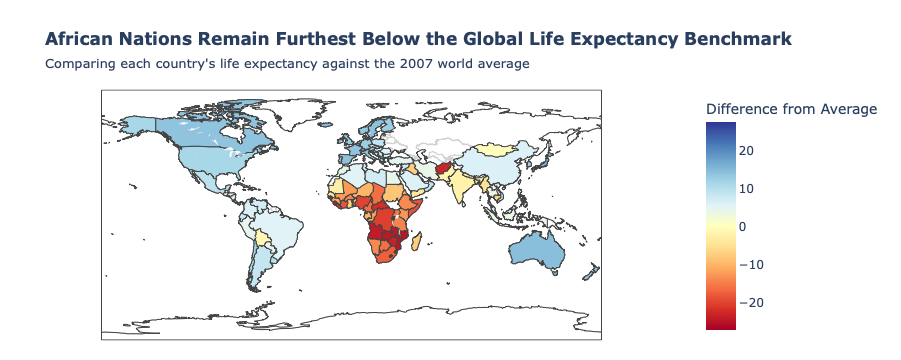

In [2]:
# Task 1
# YOUR CODE HERE
# Task 1
# WORLD CHOROPLETH — Global life expectancy comparison

import pandas as pd
import plotly.express as px

# Load Gapminder dataset
gap = px.data.gapminder()

# Keep only 2007 data
life_2007 = gap[gap["year"] == 2007].copy()

# Calculate world average life expectancy
avg_life = life_2007["lifeExp"].mean()

# Create deviation column
life_2007["difference"] = life_2007["lifeExp"] - avg_life

# Build choropleth map
fig1 = px.choropleth(
    life_2007,
    locations="iso_alpha",
    color="difference",
    hover_name="country",

    hover_data={
        "lifeExp": ":.1f",
        "difference": ":.1f",
        "iso_alpha": False
    },

    color_continuous_scale="RdYlBu",
    color_continuous_midpoint=0,

    labels={
        "difference": "Difference from Average",
        "lifeExp": "Life Expectancy"
    },

    title="<b>African Nations Remain Furthest Below the Global Life Expectancy Benchmark</b><br><span style='font-size:13px'>Comparing each country's life expectancy against the 2007 world average</span>"
)

# Geographic styling
fig1.update_geos(
    showcountries=True,
    countrycolor="lightgray",
    projection_type="equirectangular"
)

# Layout styling
fig1.update_layout(
    template="plotly_white",
    font=dict(size=12),
    margin=dict(t=90, l=20, r=20, b=20)
)

fig1.show()

## Task 2 — Find your own GeoJSON

**What to build:** A choropleth using a GeoJSON file you find yourself online.

**Requirements:**
- Find a free GeoJSON file for any geography that interests you (country, region, city)
- Create or find a matching dataset with at least one numeric variable per region
- Build either a `px.choropleth` or `px.choropleth_mapbox` — state your choice and reason in the markdown cell below
- Correctly identify and set `featureidkey` by inspecting the GeoJSON properties
- Choose sequential or diverging scale — state your reason in the markdown cell below
- Insight title naming a geographic finding

**Where to find GeoJSON files:**
- [geojson.xyz](https://geojson.xyz/) — countries, cities, natural features
- [naturalearthdata.com](https://www.naturalearthdata.com/) — global admin boundaries
- [github.com/datasets/geo-countries](https://github.com/datasets/geo-countries) — country polygons
- Search: `[country name] [admin level] GeoJSON github` — most countries have free boundary files on GitHub

> 💡 Before plotting, always inspect your GeoJSON properties first:
> ```python
> print(my_geojson['features'][0]['properties'])
> ```
> The property name that matches your dataframe's location column is what goes in `featureidkey='properties.???'`


### Task 2 — Design decisions

**GeoJSON source:** *(URL or description)*

**Chart type chosen** (`px.choropleth` or `px.choropleth_mapbox`) **and reason:**

*Your answer here*

**Colour scale chosen** (sequential or diverging) **and reason:**

*Your answer here*


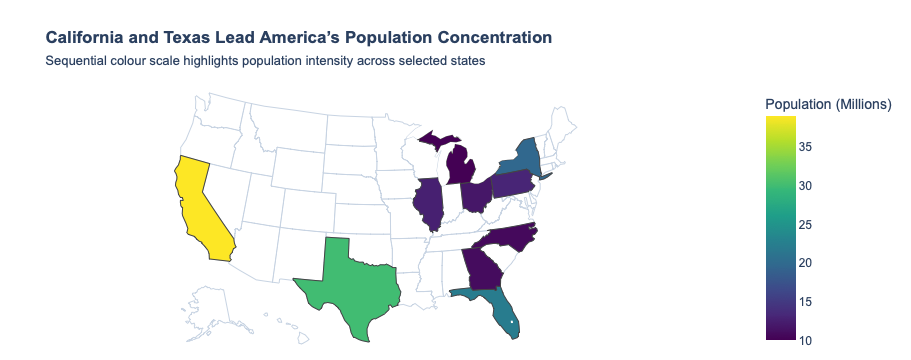

In [3]:
# Task 2
# YOUR CODE HERE

# Load your GeoJSON
# with open('your_file.geojson', 'r') as file:
#     my_geojson = json.load(file)

# Inspect the properties to find the right featureidkey
# print(my_geojson['features'][0]['properties'])
# Task 2
# USA CHOROPLETH — Population distribution by state

import pandas as pd
import plotly.express as px

# Create dataset
states = pd.DataFrame({

    "Code": ["CA", "TX", "FL", "NY", "PA",
             "IL", "OH", "GA", "NC", "MI"],

    "State": ["California", "Texas", "Florida", "New York",
              "Pennsylvania", "Illinois", "Ohio",
              "Georgia", "North Carolina", "Michigan"],

    "Population": [39.0, 30.0, 22.2, 19.7,
                   13.0, 12.6, 11.8,
                   10.9, 10.7, 10.0]
})

# Create map
fig2 = px.choropleth(
    states,

    locations="Code",
    locationmode="USA-states",

    color="Population",

    hover_name="State",

    color_continuous_scale="Viridis",

    labels={
        "Population": "Population (Millions)"
    },

    title="<b>California and Texas Lead America’s Population Concentration</b><br><span style='font-size:13px'>Sequential colour scale highlights population intensity across selected states</span>"
)

# Restrict map to USA
fig2.update_geos(
    scope="usa",
    lakecolor="white",
    showlakes=True
)

# Layout formatting
fig2.update_layout(
    template="plotly_white",
    margin=dict(t=85, l=10, r=10, b=10),
    font=dict(family="Arial")
)

fig2.show()